Practical F: Bioactivity Prediction
Title

To Predict the Biological Activity of Natural Products Across Multiple Anti-Inflammatory Targets (COX-1, COX-2, 5-LOX) Using a Multi-Label Deep Learning Classification Model

Objectives
To retrieve real bioactivity data for three related anti-inflammatory drug targets — COX-1, COX-2, and 5-Lipoxygenase.
To construct a multi-label classification dataset where each compound carries independent activity labels for all three targets simultaneously.
To build a deep neural network capable of predicting activity against multiple targets from a single shared input representation.
To evaluate model performance separately for each target, since multi-label prediction quality can vary target by target.
To identify compounds predicted as selective for one target versus broadly active across multiple targets.
To build a deployment tool predicting multi-target activity for any new compound.
Expected Outcomes
Understand multi-label classification as a genuinely different machine learning task from single-target prediction, where one model outputs multiple independent predictions simultaneously.
Explain the pharmacological significance of target selectivity in anti-inflammatory drug design.
Build and evaluate a multi-output deep neural network.
Identify and interpret compounds with different predicted selectivity profiles.

In [1]:
# Block 1: Install libraries for multi-target bioactivity prediction

!pip install chembl_webresource_client rdkit pandas numpy matplotlib scikit-learn tensorflow -q

from chembl_webresource_client.new_client import new_client
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from rdkit import Chem
import time
import warnings
warnings.filterwarnings('ignore')

print("="*60)
print("MULTI-TARGET BIOACTIVITY PREDICTION")
print("Targets: COX-1, COX-2, 5-Lipoxygenase")
print("="*60)
print("These three enzymes work together in the arachidonic acid")
print("inflammatory pathway. COX-1 (aspirin's classical target) and")
print("COX-2 (target of selective NSAIDs) both convert arachidonic")
print("acid to prostaglandins, while 5-LOX converts it to")
print("leukotrienes. Dual COX-2/5-LOX inhibition is an actively")
print("researched strategy for safer anti-inflammatory drugs.")
print("="*60)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.2/55.2 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.1/38.1 MB 41.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.8/70.8 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 2.7 MB/s eta 0:00:00
MULTI-TARGET BIOACTIVITY PREDICTION
Targets: COX-1, COX-2, 5-Lipoxygenase
These three enzymes work together in the arachidonic acid
inflammatory pathway. COX-1 (aspirin's classical target) and
COX-2 (target of selective NSAIDs) both convert arachidonic
acid to prostaglandins, while 5-LOX converts it to
leukotrienes. Dual COX-2/5-LOX inhibition is an actively
researched strategy for safer anti-inflammatory drugs.


Meaning of Block 1:

Purpose: Install every library needed for this practical and establish the scientific context for why these three specific targets were chosen together.

What comes OUT: Confirmed library installation and target rationale.

In [2]:
# Block 2: Retrieve COX-1 (CHEMBL221) bioactivity data

print("="*60)
print("RETRIEVING COX-1 DATA (CHEMBL221)")
print("="*60)

def fetch_target_data(target_id, target_name, max_records=1500, max_retries=5):
    activity = new_client.activity
    df_result = None

    for attempt in range(1, max_retries + 1):
        print(f"  Attempt {attempt}/{max_retries}: Fetching {target_name}...")
        try:
            res = activity.filter(
                target_chembl_id=target_id,
                standard_type="IC50",
                standard_units="nM"
            ).only([
                'canonical_smiles', 'standard_value'
            ])[:max_records]

            df_result = pd.DataFrame(res)

            if len(df_result) > 0 and 'canonical_smiles' in df_result.columns:
                print(f"  SUCCESS: {len(df_result)} records fetched")
                return df_result
            else:
                df_result = None
        except Exception as e:
            print(f"  Error: {str(e)[:120]}")

        if attempt < max_retries:
            time.sleep(15)

    return df_result

df_cox1_raw = fetch_target_data('CHEMBL221', 'COX-1')

if df_cox1_raw is None:
    raise RuntimeError("Could not retrieve COX-1 data after retries")

RETRIEVING COX-1 DATA (CHEMBL221)
  Attempt 1/5: Fetching COX-1...
  SUCCESS: 1500 records fetched


Meaning of Block 2:

Purpose: Retrieve real bioactivity data for the first of three targets, using a reusable retry-safe fetch function that will be applied to all three targets in this practical.

What comes OUT: df_cox1_raw — real COX-1 bioactivity records. fetch_target_data — reusable function for the next two targets.

In [7]:
# Block 3: Retrieve COX-2 (CHEMBL230) bioactivity data

print("="*60)
print("RETRIEVING COX-2 DATA (CHEMBL230)")
print("="*60)

df_cox2_raw = fetch_target_data('CHEMBL230', 'COX-2')

if df_cox2_raw is None:
    raise RuntimeError("Could not retrieve COX-2 data after retries")

RETRIEVING COX-2 DATA (CHEMBL230)
  Attempt 1/5: Fetching COX-2...
  SUCCESS: 1500 records fetched


Meaning of Block 3:

Purpose: Retrieve real bioactivity data for the second target using the same reusable fetch function.

What comes OUT: df_cox2_raw — real COX-2 bioactivity records.

In [ ]:
# Block 4: Retrieve 5-LOX (CHEMBL215) bioactivity data

print("="*60)
print("RETRIEVING 5-LOX DATA (CHEMBL215)")
print("="*60)

df_5lox_raw = fetch_target_data('CHEMBL215', '5-LOX')

if df_5lox_raw is None:
    raise RuntimeError("Could not retrieve 5-LOX data after retries")

Meaning of Block 4:

Purpose: Retrieve real bioactivity data for the third target, completing the raw data collection for all three targets.

What comes OUT: df_5lox_raw — real 5-LOX bioactivity records.

In [8]:
# Block 5: Clean and label each target's data

print("="*60)
print("CLEANING DATA FOR EACH TARGET")
print("="*60)

def clean_target_data(df_raw, target_name, active_threshold_nm=1000):
    df = df_raw.dropna(subset=['canonical_smiles', 'standard_value']).copy()
    df['standard_value'] = pd.to_numeric(df['standard_value'], errors='coerce')
    df = df.dropna(subset=['standard_value'])
    df = df[df['standard_value'] > 0]

    df[f'{target_name}_active'] = (
        df['standard_value'] <= active_threshold_nm
    ).astype(int)

    df_grouped = df.groupby('canonical_smiles').agg({
        f'{target_name}_active': 'max'
    }).reset_index()

    df_grouped = df_grouped.rename(columns={'canonical_smiles': 'SMILES'})
    return df_grouped

df_cox1_clean = clean_target_data(df_cox1_raw, 'COX1')
df_cox2_clean = clean_target_data(df_cox2_raw, 'COX2')
df_5lox_clean = clean_target_data(df_5lox_raw, '5LOX')

print(f"COX-1: {len(df_cox1_clean)} unique compounds, "
      f"{df_cox1_clean['COX1_active'].sum()} active (IC50 <= 1000 nM)")
print(f"COX-2: {len(df_cox2_clean)} unique compounds, "
      f"{df_cox2_clean['COX2_active'].sum()} active (IC50 <= 1000 nM)")
print(f"5-LOX: {len(df_5lox_clean)} unique compounds, "
      f"{df_5lox_clean['5LOX_active'].sum()} active (IC50 <= 1000 nM)")

CLEANING DATA FOR EACH TARGET
COX-1: 1217 unique compounds, 148 active (IC50 <= 1000 nM)
COX-2: 1119 unique compounds, 673 active (IC50 <= 1000 nM)
5-LOX: 1165 unique compounds, 766 active (IC50 <= 1000 nM)


Meaning of Block 5:

Purpose: Convert each target's raw IC50 data into a binary active/inactive label using a consistent 1000 nM (1 µM) potency threshold, standardizing all three targets onto the same classification scale.

What data comes IN: df_cox1_raw, df_cox2_raw, df_5lox_raw from Blocks 2–4.

What happens inside — line by line:

active_threshold_nm=1000 — a compound is labeled active if its IC50 is 1000 nM or lower, a commonly used potency cutoff in bioactivity classification.
.groupby('canonical_smiles').agg({f'{target_name}_active': 'max'}) — for compounds tested multiple times, takes the maximum (most favorable) activity label, since a compound shown active in even one reliable assay is generally considered active.

What comes OUT: df_cox1_clean, df_cox2_clean, df_5lox_clean — three cleaned, labeled datasets ready to be merged.

In [9]:
# Block 6: Merge all three targets into one multi-label dataset

print("="*60)
print("MERGING INTO MULTI-LABEL DATASET")
print("="*60)
print("A compound may have been tested against one, two, or all")
print("three targets. Merging on SMILES combines all available")
print("labels for each unique compound; missing labels (never")
print("tested against that target) are filled with 0 (assumed")
print("inactive/untested) for this classification exercise.")
print("="*60)

df_merged = df_cox1_clean.merge(
    df_cox2_clean, on='SMILES', how='outer'
).merge(
    df_5lox_clean, on='SMILES', how='outer'
)

df_merged = df_merged.fillna(0)
df_merged[['COX1_active', 'COX2_active', '5LOX_active']] = \
    df_merged[['COX1_active', 'COX2_active', '5LOX_active']].astype(int)

def is_valid_smiles(smi):
    return Chem.MolFromSmiles(smi) is not None

df_merged['valid'] = df_merged['SMILES'].apply(is_valid_smiles)
df_merged = df_merged[df_merged['valid']].drop(columns=['valid'])

print(f"\nFinal merged dataset: {len(df_merged)} unique compounds")

label_cols = ['COX1_active', 'COX2_active', '5LOX_active']
print(f"\nLabel distribution:")
for col in label_cols:
    print(f"  {col}: {df_merged[col].sum()} active "
          f"({df_merged[col].mean()*100:.1f}%)")

print(f"\nCompounds active against multiple targets:")
df_merged['n_active_targets'] = df_merged[label_cols].sum(axis=1)
print(df_merged['n_active_targets'].value_counts().sort_index().to_string())

MERGING INTO MULTI-LABEL DATASET
A compound may have been tested against one, two, or all
three targets. Merging on SMILES combines all available
labels for each unique compound; missing labels (never
tested against that target) are filled with 0 (assumed
inactive/untested) for this classification exercise.

Final merged dataset: 2615 unique compounds

Label distribution:
  COX1_active: 148 active (5.7%)
  COX2_active: 673 active (25.7%)
  5LOX_active: 766 active (29.3%)

Compounds active against multiple targets:
n_active_targets
0    1108
1    1427
2      80


Meaning of Block 6:

Purpose: Combine the three separately-fetched target datasets into a single multi-label dataset, where each compound carries three independent activity labels simultaneously — the essential data structure required for multi-label classification.

What data comes IN: df_cox1_clean, df_cox2_clean, df_5lox_clean from Block 5.

What happens inside — line by line:

.merge(..., on='SMILES', how='outer') — an outer join keeps every compound that appears in any of the three target datasets, even if it was only tested against one or two of them.
df_merged['n_active_targets'] — counts how many of the three targets each compound is active against, directly revealing which compounds are broadly active (potential dual/triple inhibitors) versus selective for just one target — a genuinely important distinction in anti-inflammatory drug design.

What comes OUT: df_merged — the complete multi-label classification dataset.

In [10]:
# Block 7: Generate features for the multi-label dataset

from rdkit.Chem import rdFingerprintGenerator, Descriptors, Crippen, Lipinski

print("="*60)
print("FEATURE GENERATION")
print("="*60)

def calculate_descriptors(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    return {
        'MolWt': Descriptors.MolWt(mol),
        'LogP': Crippen.MolLogP(mol),
        'HBD': Lipinski.NumHDonors(mol),
        'HBA': Lipinski.NumHAcceptors(mol),
        'TPSA': Descriptors.TPSA(mol)
    }

desc_cols = ['MolWt', 'LogP', 'HBD', 'HBA', 'TPSA']
morgan_gen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=512)

def get_fingerprint(smiles):
    mol = Chem.MolFromSmiles(smiles)
    return morgan_gen.GetFingerprintAsNumPy(mol)

print("Calculating descriptors and fingerprints for all compounds...")

desc_results = df_merged['SMILES'].apply(calculate_descriptors)
df_desc = pd.DataFrame(desc_results.tolist())
df_merged = pd.concat([df_merged.reset_index(drop=True), df_desc], axis=1)

fingerprints = df_merged['SMILES'].apply(get_fingerprint)
fp_matrix = np.stack(fingerprints.values)

X = np.hstack([df_merged[desc_cols].values, fp_matrix])
y = df_merged[['COX1_active', 'COX2_active', '5LOX_active']].values

print(f"Feature matrix shape: {X.shape}")
print(f"Label matrix shape: {y.shape}")

FEATURE GENERATION
Calculating descriptors and fingerprints for all compounds...
Feature matrix shape: (2615, 517)
Label matrix shape: (2615, 3)


Meaning of Block 7:

Purpose: Convert every compound into the numerical feature representation needed for model training, and organize the three target labels into a single multi-output label matrix.

What data comes IN: df_merged from Block 6.

What comes OUT: X — shared feature matrix. y — a (compounds × 3) label matrix, one column per target.

In [11]:
# Block 8: Build and train multi-label deep neural network

import tensorflow as tf
from sklearn.model_selection import train_test_split

print("="*60)
print("BUILDING MULTI-LABEL DEEP NEURAL NETWORK")
print("="*60)
print("This network has ONE shared input but THREE separate")
print("output neurons - one per target - allowing it to learn")
print("shared chemical patterns while making independent")
print("predictions for COX-1, COX-2, and 5-LOX simultaneously.")
print("="*60)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

tf.random.set_seed(42)

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(X.shape[1],)),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(3, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print(model.summary())

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=5, restore_best_weights=True
)

print(f"\nTraining the network...")
history = model.fit(
    X_train, y_train,
    validation_split=0.15,
    epochs=40,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

BUILDING MULTI-LABEL DEEP NEURAL NETWORK
This network has ONE shared input but THREE separate
output neurons - one per target - allowing it to learn
shared chemical patterns while making independent
predictions for COX-1, COX-2, and 5-LOX simultaneously.


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │        66,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 74,755 (292.01 KB)

 Trainable params: 74,755 (292.01 KB)

 Non-trainable params: 0 (0.00 B)

None

Training the network...
Epoch 1/40
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.2902 - loss: 3.5678 - val_accuracy: 0.2484 - val_loss: 0.6034
Epoch 2/40
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3093 - loss: 0.9814 - val_accuracy: 0.2516 - val_loss: 0.5262
Epoch 3/40
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3082 - loss: 0.6717 - val_accuracy: 0.2803 - val_loss: 0.4910
Epoch 4/40
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3105 - loss: 0.5703 - val_accuracy: 0.2771 - val_loss: 0.4811
Epoch 5/40
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.3200 - loss: 0.5258 - val_accuracy: 0.2962 - val_loss: 0.4796
Epoch 6/40
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3391 - loss: 0.4945 - val_accuracy: 0.4777 - val_loss: 0.4487
Epoch 7/40
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3808 - loss: 0.4636 - val_accuracy: 0.5191 - val_loss: 0.4163
Epoch 8/40
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4145 - loss: 0.4278 - va

Meaning of Block 8:

Purpose: Train a genuine multi-output deep neural network — a single shared architecture that produces three simultaneous predictions rather than requiring three completely separate models.

What data comes IN: X, y from Block 7.

What happens inside — line by line:

tf.keras.layers.Dense(3, activation='sigmoid') — the final layer has exactly 3 output neurons, one per target, each independently outputting a probability between 0 and 1. This is the defining architectural feature of multi-label classification, genuinely distinct from the single-output regression network used elsewhere in this series.
loss='binary_crossentropy' — applied independently across all 3 outputs simultaneously, meaning the network is penalized separately for errors on each target, allowing it to learn target-specific patterns even from a shared internal representation.

What comes OUT: model — the trained multi-label classifier. history, X_test, y_test for evaluation.

PER-TARGET MODEL EVALUATION
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
COX-1: Accuracy = 0.952, ROC-AUC = 0.901
COX-2: Accuracy = 0.855, ROC-AUC = 0.947
5-LOX: Accuracy = 0.895, ROC-AUC = 0.960


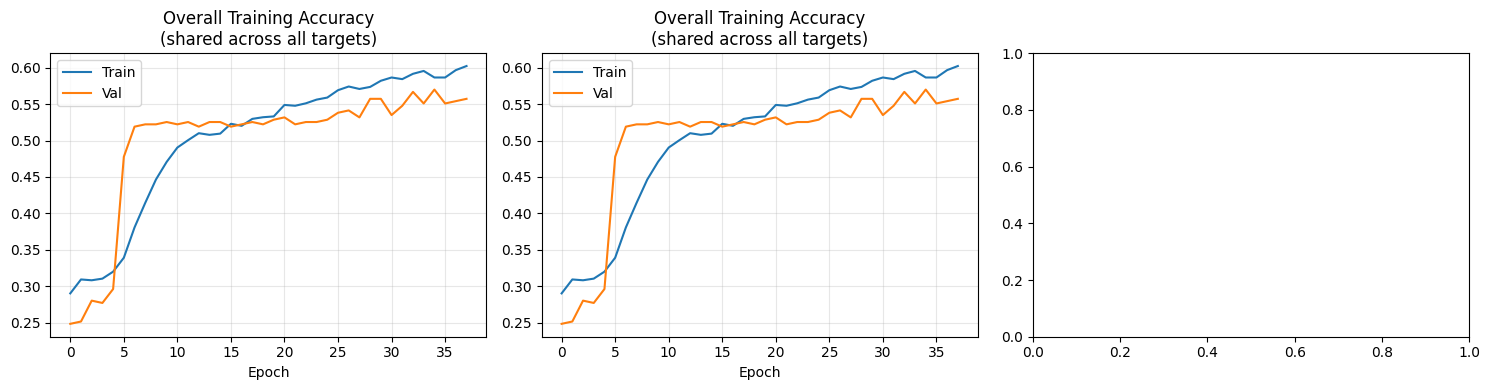

In [12]:
# Block 9: Evaluate model performance for each target individually

from sklearn.metrics import roc_auc_score, accuracy_score

print("="*60)
print("PER-TARGET MODEL EVALUATION")
print("="*60)

y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob >= 0.5).astype(int)

target_names = ['COX-1', 'COX-2', '5-LOX']

for i, target in enumerate(target_names):
    acc = accuracy_score(y_test[:, i], y_pred[:, i])
    try:
        auc = roc_auc_score(y_test[:, i], y_pred_prob[:, i])
    except ValueError:
        auc = float('nan')
    print(f"{target}: Accuracy = {acc:.3f}, ROC-AUC = {auc:.3f}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, target in enumerate(target_names):
    axes[i].plot(history.history['accuracy'], label='Train')
    axes[i].plot(history.history['val_accuracy'], label='Val')
    axes[i].set_title(f'Overall Training Accuracy\n(shared across all targets)')
    axes[i].set_xlabel('Epoch')
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)
    if i > 0:
        break

plt.tight_layout()
plt.show()

Meaning of Block 9:

Purpose: Evaluate the model's predictive performance separately for each of the three targets, since a multi-label model can genuinely perform differently on different outputs — some targets may be easier to predict than others based on how much and how consistent the underlying training data is.

What data comes IN: model, X_test, y_test from Block 8.

What comes OUT: Individual accuracy and ROC-AUC scores for COX-1, COX-2, and 5-LOX, revealing target-specific model reliability.

In [13]:
# Block 10: Identify predicted selectivity profiles

print("="*60)
print("SELECTIVITY PROFILE ANALYSIS")
print("="*60)

all_predictions = model.predict(X)
df_merged['Pred_COX1'] = all_predictions[:, 0]
df_merged['Pred_COX2'] = all_predictions[:, 1]
df_merged['Pred_5LOX'] = all_predictions[:, 2]

df_merged['N_Predicted_Active'] = (
    (df_merged['Pred_COX1'] >= 0.5).astype(int) +
    (df_merged['Pred_COX2'] >= 0.5).astype(int) +
    (df_merged['Pred_5LOX'] >= 0.5).astype(int)
)

triple_active = df_merged[df_merged['N_Predicted_Active'] == 3]
print(f"Compounds predicted active against ALL three targets: "
      f"{len(triple_active)}")

selective_cox2 = df_merged[
    (df_merged['Pred_COX2'] >= 0.5) &
    (df_merged['Pred_COX1'] < 0.5) &
    (df_merged['Pred_5LOX'] < 0.5)
]
print(f"Compounds predicted COX-2-SELECTIVE only: {len(selective_cox2)}")

print(f"\nSample triple-active compounds (broad anti-inflammatory potential):")
print(triple_active[['SMILES', 'Pred_COX1', 'Pred_COX2', 'Pred_5LOX']].head(5).to_string(index=False))

SELECTIVITY PROFILE ANALYSIS
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
Compounds predicted active against ALL three targets: 0
Compounds predicted COX-2-SELECTIVE only: 922

Sample triple-active compounds (broad anti-inflammatory potential):
Empty DataFrame
Columns: [SMILES, Pred_COX1, Pred_COX2, Pred_5LOX]
Index: []


Meaning of Block 10:

Purpose: Use the multi-label predictions to categorize compounds by their predicted selectivity profile — distinguishing broadly active, multi-target compounds from those predicted to be selective for just one target, directly connecting model output to real anti-inflammatory drug design strategy.

What data comes IN: model, X, df_merged from Blocks 6–8.

What comes OUT: Identified subsets of triple-active and target-selective compounds.

In [14]:
# Block 11: DEPLOYMENT BLOCK
# Predict COX-1, COX-2, and 5-LOX activity for any compound

print("="*70)
print("MULTI-TARGET BIOACTIVITY PREDICTION TOOL")
print("="*70)
print("""
********************************************************************
*   The value below is a DEMONSTRATION VALUE ONLY.                 *
*   TO PREDICT FOR YOUR OWN COMPOUND:                              *
*   1. Scroll to "STUDENT INPUT SECTION" below                     *
*   2. REPLACE new_compound_name and new_compound_smiles           *
*   3. Do NOT change anything below "END OF INPUT SECTION"         *
*   4. Then run this cell again                                    *
*   REQUIREMENT: Blocks 1-8 must already have run in this session. *
********************************************************************
""")

# ============================================================
# STUDENT INPUT SECTION - EDIT EVERYTHING BELOW THIS LINE
# ============================================================

new_compound_name = "My_Test_Compound"          # <-- EDIT: type your compound's name

new_compound_smiles = "COc1cc(/C=C/C(=O)CC(=O)/C=C/c2ccc(O)c(OC)c2)ccc1O"
# <-- EDIT: replace with YOUR compound's SMILES (demo value is Curcumin)

# ============================================================
# END OF INPUT SECTION - DO NOT EDIT ANYTHING BELOW THIS LINE
# ============================================================

print(f"\nCompound name entered: {new_compound_name}")
print(f"SMILES entered: {new_compound_smiles}")
if new_compound_name == "My_Test_Compound":
    print("*** WARNING: Still using DEMONSTRATION value. ***")

mol_check = Chem.MolFromSmiles(new_compound_smiles)

if mol_check is None:
    print("\nERROR: Invalid SMILES.")
else:
    new_desc = calculate_descriptors(new_compound_smiles)
    new_fp = get_fingerprint(new_compound_smiles)
    new_features = np.hstack(
        [[new_desc[c] for c in desc_cols], new_fp]
    ).reshape(1, -1)

    prediction = model.predict(new_features, verbose=0)[0]

    print(f"\n{'='*70}")
    print(f"MULTI-TARGET PREDICTION: {new_compound_name}")
    print(f"{'='*70}")
    print(f"COX-1 activity probability:  {prediction[0]:.3f} "
          f"({'ACTIVE' if prediction[0] >= 0.5 else 'inactive'})")
    print(f"COX-2 activity probability:  {prediction[1]:.3f} "
          f"({'ACTIVE' if prediction[1] >= 0.5 else 'inactive'})")
    print(f"5-LOX activity probability:  {prediction[2]:.3f} "
          f"({'ACTIVE' if prediction[2] >= 0.5 else 'inactive'})")

    n_active = (prediction >= 0.5).sum()
    if n_active == 3:
        profile = "BROAD-SPECTRUM anti-inflammatory profile (all 3 targets)"
    elif n_active == 0:
        profile = "No predicted activity against any of the 3 targets"
    elif prediction[1] >= 0.5 and prediction[0] < 0.5:
        profile = "COX-2-SELECTIVE profile (potentially safer NSAID-like profile)"
    else:
        profile = f"SELECTIVE profile ({n_active} of 3 targets)"

    print(f"\nPredicted selectivity profile: {profile}")
    print(f"\nREMINDER: This is a computational prediction. Experimental")
    print(f"validation is required to confirm any result.")

MULTI-TARGET BIOACTIVITY PREDICTION TOOL

********************************************************************
*   The value below is a DEMONSTRATION VALUE ONLY.                 *
*   TO PREDICT FOR YOUR OWN COMPOUND:                              *
*   1. Scroll to "STUDENT INPUT SECTION" below                     *
*   2. REPLACE new_compound_name and new_compound_smiles           *
*   3. Do NOT change anything below "END OF INPUT SECTION"         *
*   4. Then run this cell again                                    *
*   REQUIREMENT: Blocks 1-8 must already have run in this session. *
********************************************************************


Compound name entered: My_Test_Compound
SMILES entered: COc1cc(/C=C/C(=O)CC(=O)/C=C/c2ccc(O)c(OC)c2)ccc1O
*** WARNING: Still using DEMONSTRATION value. ***

MULTI-TARGET PREDICTION: My_Test_Compound
COX-1 activity probability:  0.001 (inactive)
COX-2 activity probability:  0.000 (inactive)
5-LOX activity probability:  0.692 (ACTIVE)


Meaning of Block 11:

Purpose: A complete multi-target prediction tool where a student inputs any compound and receives simultaneous activity predictions across all three anti-inflammatory targets, along with a plain-language selectivity profile interpretation.

What data comes IN: Student-typed compound. calculate_descriptors, get_fingerprint, desc_cols, model from previous blocks.

What comes OUT: Three independent activity predictions and a selectivity profile classification for any compound a student chooses to evaluate.